## Imports

Import configuration, array-processing and forward-modeling utilities. Start the notebook from the repository root and run the cells in order.

（导入配置、数组处理和正演工具。从仓库根目录启动Notebook，按顺序执行）


In [185]:
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path

import numpy as np
from scipy.signal import hilbert
from seiswav import forward_model


## Configuration

Define paths, sampling dimensions, random seeds, data splits and wavelet parameters. Time is the last axis, and the VAE downsamples by a factor of four.

（集中定义路径、采样尺寸、随机种子、数据划分和子波参数。时间轴为最后一维，VAE是四倍压缩）


In [186]:
@dataclass
class GenConfig:
    model_path: str = 'train_ckpt/ldm_3d_controlnet'
    data_root: str = '../../../../datasets/private/fold_fault'
    source_pattern: str = '**/*label.npy'
    save_root: str = 'outputs/generated'
    device: str = 'cuda:0'
    latent_shape: tuple = (32, 32, 32)
    cube_size: tuple = (128, 128, 128) # also 144 and latent shape should be set to 36
    num_samples: int = 1
    num_valid_samples: int = 0
    last_sample: int = 0
    seed: int = 42
    split_seed: int = 2026
    valid_fraction: float = 0.0  # Set >0 when generating a separate validation split.
    guidance_scale: float = 3.0  # Scale for classifier-free guidance during generation. Bigger values make the model follow the conditioning more strictly.
    conditioning_scale: float = 1.0
    num_inference_steps: int = 25
    # Must match the selected model's training normalization; never guess from values.
    impedance_domain: str = 'linear'
    imp_src_min: float = 5122842.0  # Can be easily obtained from your well logs.
    imp_src_max: float = 8870921.0
    dt: float = 0.001
    wavelet_length: float = 0.100
    ricker_probability: float = 0.7
    freq_range: tuple = (25.0, 50.0)
    zero_phase_probability: float = 0.5
    phase_range: tuple = (-30.0, 30.0)


## Run configuration


In [187]:
cfg = GenConfig()
cfg.seed = int(np.random.default_rng().integers(0, 1_000_000)) 
# cfg.seed = 461274
cfg


GenConfig(model_path='train_ckpt/ldm_3d_controlnet', data_root='../../../../datasets/private/fold_fault', source_pattern='**/*label.npy', save_root='outputs/generated', device='cuda:0', latent_shape=(32, 32, 32), cube_size=(128, 128, 128), num_samples=1, num_valid_samples=0, last_sample=0, seed=882060, split_seed=2026, valid_fraction=0.0, guidance_scale=3.0, conditioning_scale=1.0, num_inference_steps=25, impedance_domain='linear', imp_src_min=5122842.0, imp_src_max=8870921.0, dt=0.001, wavelet_length=0.1, ricker_probability=0.7, freq_range=(25.0, 50.0), zero_phase_probability=0.5, phase_range=(-30.0, 30.0))

## Fault label preparation

Fault labels with a size of 256 are available in [this folder](https://drive.google.com/drive/folders/1awGjszP74W_2sZT8u1rzSzkhPMJXoVPC?usp=drive_link). Using these labels as conditions is recommended: the model was not trained to interpret arbitrary fault conditions, so other fault labels may yield poorer results. Alternatively, an all-zero label can be supplied; the generated data will still contain fault structures. Labels are randomly cropped from 256 to 128, or to the specified `cube_size`.

（断层标签条件这里提供在https://drive.google.com/drive/folders/1awGjszP74W_2sZT8u1rzSzkhPMJXoVPC?usp=drive_link中（大小为256），这里建议使用这里的标签当作条件，因为在训练条件中，并没有对断层条件做一个通用的识别，可能使用其他断层条件时效果不佳，或者直接给一个全为0的标签，生成的数据中也会带有断层信息。这里会将256随机裁剪成128或者你指定的cube_size）


In [188]:
def prepare_fault_condition(config, source, rng):
    """Crop one binary fault channel; no paired impedance source is needed."""
    import torch
    labels = np.load(source, mmap_mode='r', allow_pickle=False)
    if labels.ndim != 3 or any(a < b for a, b in zip(labels.shape, config.cube_size)):
        raise ValueError(f'{source}: shape {labels.shape} cannot fit {config.cube_size}')
    starts = [int(rng.integers(a - b + 1)) for a, b in zip(labels.shape, config.cube_size)]
    slices = tuple(slice(a, a + b) for a, b in zip(starts, config.cube_size))
    patch = np.asarray(labels[slices])
    if not np.isfinite(patch).all():
        raise ValueError(f'Nonfinite fault labels: {source}')
    fault = (patch > 0).astype(np.float32)
    return torch.from_numpy(fault)[None, None], starts, {'fault_condition': fault}



## Source-file splitting

This step only sets aside a subset of the labels for inversion validation.

（这里只是为了从所有标签中划分出用于反演验证的标签）


In [189]:
def split_sources(config):
    """Assign sources by stable filename hash; added files never move existing sources."""
    if not 0 <= config.valid_fraction < 1:
        raise ValueError('valid_fraction must be in [0, 1)')
    groups = {'train': [], 'valid': []}
    assignments = {}
    for path in sorted(Path(config.data_root).glob(config.source_pattern)):
        arr = np.load(path, mmap_mode='r', allow_pickle=False)
        if arr.ndim != 3 or any(a < b for a, b in zip(arr.shape, config.cube_size)):
            raise ValueError(f'{path}: shape {arr.shape} cannot fit {config.cube_size}')
        source_id = path.relative_to(Path(config.data_root)).as_posix()
        digest = hashlib.sha256(f'{config.split_seed}:{source_id}'.encode()).digest()
        split = 'valid' if int.from_bytes(digest[:8], 'big') / 2**64 < config.valid_fraction else 'train'
        groups[split].append(path)
        assignments[source_id] = split
    if not assignments:
        raise FileNotFoundError(f'No fault labels matching {config.source_pattern} in {config.data_root}')
    if (config.num_samples and not groups['train']) or (config.num_valid_samples and not groups['valid']):
        raise ValueError('Source split is empty; supply more source files or choose another split_seed')
    return groups, assignments



## Input availability check

List matching labels and report the model-path status. Missing files are reported without preventing you from reviewing or editing the subsequent function definitions; the inputs must be available before actual generation.

（列出匹配的标签和模型路径状态。文件尚未补充时只提示缺失，允许继续查看和修改后面的函数定义；真正生成时必须提供输入。）


In [190]:
model_dir = Path(cfg.model_path)
label_files = sorted(Path(cfg.data_root).glob(cfg.source_pattern))
print(f'Model export: {model_dir.resolve()}')
print(f'Model index available: {(model_dir / "model_index.json").is_file()}')
print(f'Label root: {Path(cfg.data_root).resolve()}')
print(f'Matched labels: {len(label_files)}')
for path in label_files[:20]:
    print('  ', path.relative_to(Path(cfg.data_root)))
if len(label_files) > 20:
    print(f'  ... {len(label_files) - 20} more files')
if not label_files:
    print('Add label files before running generation.')


Model export: D:\Code\github\my_work\geovoldiff\train_ckpt\ldm_3d_controlnet
Model index available: True
Label root: D:\datasets\private\fold_fault
Matched labels: 42
   fault10_label.npy
   fault11_label.npy
   fault12_label.npy
   fault13_label.npy
   fault14_label.npy
   fault15_label.npy
   fault16_label.npy
   fault17_label.npy
   fault18_label.npy
   fault19_label.npy
   fault1_label.npy
   fault20_label.npy
   fault21_label.npy
   fault22_label.npy
   fault23_label.npy
   fault24_label.npy
   fault25_label.npy
   fault26_label.npy
   fault27_label.npy
   fault28_label.npy
  ... 22 more files


## Standardization

Compute per-volume z-scores and record the mean and standard deviation so that the original values can be recovered. The standardized data can be used directly for subsequent inversion training.

（逐体计算 z-score，并记录均值、标准差，便于恢复标准化前的数值。在后续反演训练中可以直接使用。）


In [191]:
def standardize(array):
    """Return float32 z-scores and invertible, per-volume transform metadata."""
    array = np.asarray(array, dtype=np.float64)
    if not np.isfinite(array).all():
        raise ValueError('Volume contains non-finite values')
    mean, std = float(array.mean()), float(array.std())
    if std <= 1e-12:
        raise ValueError('Cannot standardize a constant volume')
    return ((array - mean) / std).astype(np.float32), {'mean': mean, 'std': std}



## Random wavelets

Sample a Ricker or Ormsby wavelet according to the configuration, then apply a random phase. Wavelets have odd lengths, are centered and are normalized by their peak amplitude.

（按配置采样 Ricker 或 Ormsby 子波，再施加随机相位。子波长度为奇数，中心对齐，并按峰值归一化。）


In [192]:
def sample_wavelet(config, rng):
    """Draw a centered Ricker or trapezoidal-spectrum Ormsby wavelet."""
    if config.dt <= 0 or config.wavelet_length <= 0:
        raise ValueError('Wavelet dt and length must be positive')
    half = max(1, int(round(config.wavelet_length / (2 * config.dt))))
    t = np.arange(-half, half + 1) * config.dt
    if rng.random() < config.ricker_probability:
        freq = float(rng.uniform(*config.freq_range))
        if not 0 < freq < 0.5 / config.dt:
            raise ValueError('Ricker frequency must be below Nyquist')
        a = (np.pi * freq * t) ** 2
        wavelet = (1 - 2 * a) * np.exp(-a)
        meta = {'type': 'ricker', 'freq': freq}
    else:
        # Ordered corners vary both the passband and the transition widths.
        f1 = float(rng.uniform(3, 10))
        f2 = f1 + float(rng.uniform(5, 12))
        f3 = max(f2 + 10, float(rng.uniform(30, 60)))
        f4 = f3 + float(rng.uniform(10, 25))
        if f4 >= 0.5 / config.dt:
            raise ValueError('Ormsby corner frequency must be below Nyquist')
        def ramp(f):
            return f ** 2 * np.sinc(f * t) ** 2
        wavelet = ((ramp(f4) - ramp(f3)) / (f4 - f3)
                   - (ramp(f2) - ramp(f1)) / (f2 - f1))
        meta = {'type': 'ormsby', 'corners_hz': [f1, f2, f3, f4]}
    phase = (0.0 if rng.random() < config.zero_phase_probability
             else float(rng.uniform(*config.phase_range)))
    radians = np.deg2rad(phase)
    wavelet = np.cos(radians) * wavelet - np.sin(radians) * hilbert(wavelet).imag
    wavelet -= wavelet.mean()
    wavelet /= np.max(np.abs(wavelet))
    meta.update(dt=config.dt, length=float(t[-1] - t[0]), phase_deg=phase,
                normalization='peak', center_index=half)
    return wavelet.astype(np.float32), meta



## Forward modeling

Clip model output to `[-1, 1]`, map it to the retained impedance range, take log impedance and perform forward modeling along the last axis. Apply z-score standardization separately to seismic and log impedance. Metadata records the mapping, clipping fraction, wavelet and normalization statistics.

（将模型输出裁剪到 `[-1, 1]` 后映射到保留的阻抗范围，取 log 阻抗并沿最后一维正演。地震和 log 阻抗分别做 z-score。元数据记录映射、裁剪比例、子波和标准化统计量。）


In [193]:
def make_pair(images, config, rng):
    """Forward model physical log impedance, then standardize input and label separately."""
    values = np.asarray(images, dtype=np.float64)
    if values.shape != tuple(config.cube_size) or not np.isfinite(values).all():
        raise ValueError(f'Expected finite cube {config.cube_size}, got {values.shape}')
    clipped_fraction = float(np.mean((values < -1) | (values > 1)))
    unit = np.clip((values + 1) / 2, 0, 1)
    mapped = unit * (config.imp_src_max - config.imp_src_min) + config.imp_src_min
    if config.impedance_domain == 'linear':
        if np.any(mapped <= 0):
            raise ValueError('Linear impedance must be positive')
        log_imp = np.log(mapped)
    elif config.impedance_domain == 'log':
        log_imp = mapped
    else:
        raise ValueError('impedance_domain must be log or linear')
    wavelet, wavelet_meta = sample_wavelet(config, rng)
    # Keep the shared forward operator and make the time-last contract explicit.
    physical_seismic = forward_model(log_imp, wavelet, time_axis=-1)
    seismic, seismic_stats = standardize(physical_seismic)
    target, target_stats = standardize(log_imp)
    return seismic, target, wavelet, {
        'wavelet': wavelet_meta,
        'normalization': {'seismic': seismic_stats, 'log_impedance': target_stats},
        'target_domain': 'zscore_log_impedance', 'clipped_fraction': clipped_fraction,
        'axis_order': ['inline', 'xline', 'time'],
    }



## Generation and saving function

Validate parameters, load the model, sample fault conditions and generate samples one at a time. Each sample saves raw model output, faults, standardized seismic, standardized log impedance, a wavelet and JSON metadata. Existing sample folders are not overwritten. Running this cell only defines the function; it does not start inference.

（校验参数、加载模型、采样断层条件并逐个生成。每个样本保存原始模型输出、断层、标准化地震、标准化 log 阻抗、子波和 JSON 元数据。已有样本目录不会覆盖。只运行本单元定义函数，不开始推理。）


In [194]:
def generate(config):
    """Generate clean fault-conditioned pairs without overwriting existing samples."""
    if config.num_samples < 0 or config.num_valid_samples < 0 or config.last_sample < 0:
        raise ValueError('Sample counts and start index must be nonnegative')
    if config.num_samples + config.num_valid_samples == 0:
        raise ValueError('Request at least one generated sample')
    if len(config.cube_size) != 3 or len(config.latent_shape) != 3 or min(*config.cube_size, *config.latent_shape) < 1:
        raise ValueError('cube_size and latent_shape must contain three positive sizes')
    if config.imp_src_max <= config.imp_src_min:
        raise ValueError('Impedance mapping bounds must be increasing')
    if config.impedance_domain not in ('linear', 'log'):
        raise ValueError('impedance_domain must be linear or log')
    if config.impedance_domain == 'linear' and config.imp_src_min <= 0:
        raise ValueError('Linear impedance bounds must be positive')
    if config.num_inference_steps < 1:
        raise ValueError('num_inference_steps must be positive')
    if config.guidance_scale < 1 or config.conditioning_scale <= 0:
        raise ValueError('Fault generation requires guidance_scale >= 1 and conditioning_scale > 0')
    groups, assignments = split_sources(config)
    root = Path(config.save_root)
    manifest = root / 'source_split.json'
    split_record = {'data_root': str(Path(config.data_root).resolve()),
                    'split_seed': config.split_seed, 'valid_fraction': config.valid_fraction,
                    'assignments': assignments}
    if manifest.exists() and json.loads(manifest.read_text()) != split_record:
        raise ValueError('Source split changed; use a new save_root')
    for split, count in (('train', config.num_samples), ('valid', config.num_valid_samples)):
        for index in range(config.last_sample, config.last_sample + count):
            if (root / split / f'{index:04d}').exists():
                raise FileExistsError(f'Sample already exists: {root / split / f"{index:04d}"}')

    # Import GPU dependencies only when generation is requested.
    import torch
    from inference.controlnet_loading import load_controlnet_pipeline

    pipe, model_info = load_controlnet_pipeline(
        config.model_path)
    pipe = pipe.to(config.device)
    pipe.unet.eval()
    factor = 2 ** (len(pipe.vae.config.block_out_channels) - 1) if pipe.vae is not None else 1
    if tuple(s * factor for s in config.latent_shape) != tuple(config.cube_size):
        raise ValueError('cube_size must equal latent_shape times the VAE downsampling factor')
    root.mkdir(parents=True, exist_ok=True)
    manifest.write_text(json.dumps(split_record, indent=2), encoding='utf-8')
    for split_id, (split, count) in enumerate((('train', config.num_samples), ('valid', config.num_valid_samples))):
        for index in range(config.last_sample, config.last_sample + count):
            seed = int(np.random.SeedSequence([config.seed, split_id, index]).generate_state(1)[0])
            rng = np.random.default_rng(seed)
            source = groups[split][int(rng.integers(len(groups[split])))]
            cond, starts, condition_arrays = prepare_fault_condition(config, source, rng)
            cond = cond.to(config.device)
            print(f'Generating {split}/{index:04d}, seed={seed}')
            with torch.no_grad():
                images = pipe(
                    T=config.latent_shape[0], H=config.latent_shape[1], W=config.latent_shape[2],
                    num_inference_steps=config.num_inference_steps,
                    generator=torch.Generator(device=config.device).manual_seed(seed),
                    show_progress=True, controlnet_cond=cond,
                    conditioning_scale=config.conditioning_scale, guidance_scale=config.guidance_scale,
                )
            model_output = images[0, 0].float().cpu().numpy()
            clean, target, wavelet, meta = make_pair(model_output, config, rng)
            folder = root / split / f'{index:04d}'
            folder.mkdir(parents=True, exist_ok=False)
            np.save(folder / 'seismic.npy', clean)
            np.save(folder / 'impedance.npy', target)
            np.save(folder / 'wavelet.npy', wavelet)
            np.save(folder / 'model_output.npy', model_output)
            for name, array in condition_arrays.items():
                np.save(folder / f'{name}.npy', array)
            meta.update(sample_index=index, split=split, seed=seed, label_file=source.relative_to(Path(config.data_root)).as_posix(),
                        patch_start=starts, cube_shape=list(clean.shape), generator_config=asdict(config),
                        model=model_info, condition_mode='fault',
                        output_mapping={'domain': config.impedance_domain,
                                        'min': config.imp_src_min, 'max': config.imp_src_max},
                        timestamp=datetime.now(timezone.utc).isoformat())
            (folder / 'config.json').write_text(json.dumps(meta, indent=2), encoding='utf-8')
    print(f'Generation complete: {root}')



## Preview function

Define slice previews of impedance, seismic and faults along three directions. Previewing only reads saved files and does not require loading the model.

（定义三个方向的阻抗、地震和断层切片预览。预览只读取已保存的文件，无需加载模型。）


In [195]:
def preview_sample(sample_dir, pos=None):
    """Preview aligned slices; optional pos uses 1-based inline, crossline and time numbers."""
    import matplotlib.pyplot as plt
    import random
    from matplotlib.colors import ListedColormap
    sample_dir = Path(sample_dir)
    fig, axes = plt.subplots(4, 3, figsize=(9, 9))
    fig.subplots_adjust(left=0.10, right=0.90, bottom=0.03, top=0.95,
                        wspace=0.04, hspace=0.06)
    for row, (filename, title, cmap) in enumerate((
        ('impedance.npy', 'Log impedance (z-score)', 'jet'),
        ('seismic.npy', 'Seismic (z-score)', 'gray'),
        ('fault_condition.npy', 'Fault condition', 'gray'),
    )):
        volume = np.load(sample_dir / filename, allow_pickle=False)
        ni, nx, nt = volume.shape
        if row == 0:
            reference_shape = volume.shape
            if pos is not None and (
                len(pos) != 3 or any(
                    not isinstance(index, (int, np.integer)) or not 1 <= index <= size
                    for index, size in zip(pos, volume.shape)
                )
            ):
                raise ValueError('pos must contain three 1-based slice numbers within the volume shape')
            inline_idx = random.randint(1, ni) if pos is None else pos[0]
            crossline_idx = random.randint(1, nx) if pos is None else pos[1]
            time_idx = random.randint(1, nt) if pos is None else pos[2]
        elif volume.shape != reference_shape:
            raise ValueError('Impedance, seismic and fault volumes must have the same shape')
        sections = (volume[inline_idx-1].T, volume[:, crossline_idx-1].T, volume[:, :, time_idx-1])
        limits = (0, 1) if row == 2 else np.percentile(volume, [2, 98])
        if row == 1:
            seismic_sections = sections
            seismic_limits = limits
        elif row == 2:
            fault_sections = sections
        for col, (section, direction) in enumerate(zip(sections, (f'Inline_{inline_idx}', f'Crossline_{crossline_idx}', f'Time_{time_idx}'))):
            ax = axes[row, col]
            im = ax.imshow(section, cmap=cmap, aspect='auto', vmin=limits[0], vmax=limits[1])
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(direction, fontsize=10, pad=5)
            if col == 0:
                ax.set_ylabel(title, fontsize=9, labelpad=8)
        bounds = axes[row, -1].get_position()
        cax = fig.add_axes([bounds.x1 + 0.005, bounds.y0 + (bounds.height - bounds.height * 0.75) / 2, 0.008, bounds.height * 0.75,])
        cbar = fig.colorbar(im, cax=cax)
        cbar.ax.tick_params(labelsize=8, length=2, pad=2)
    # Only positive fault pixels are visible; background stays transparent.
    fault_cmap = ListedColormap(['red'])
    fault_cmap.set_bad(alpha=0)
    for col, (seismic_section, fault_section) in enumerate(zip(seismic_sections, fault_sections)):
        ax = axes[3, col]
        im = ax.imshow(seismic_section, cmap='gray', aspect='auto',
                       vmin=seismic_limits[0], vmax=seismic_limits[1])
        fault_overlay = np.ma.masked_where(fault_section <= 0, np.ones_like(fault_section))
        ax.imshow(fault_overlay, cmap=fault_cmap, aspect='auto',
                  vmin=0, vmax=1, alpha=0.75, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel('Seismic + faults', fontsize=9, labelpad=8)
    bounds = axes[3, -1].get_position()
    cax = fig.add_axes([bounds.x1 + 0.005, bounds.y0 + (bounds.height - bounds.height * 0.75) / 2, 0.008, bounds.height * 0.75,])
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=8, length=2, pad=2)
    plt.show()


## Run generation

Run this cell after supplying model weights and labels. The default output folder is `outputs/generated/train/0000/`. Increase `last_sample` to generate additional samples; use a new output directory when changing the source split. Fixed configuration, seeds and weights reproduce the experiment's random inputs.

（模型权重和标签补齐后运行本单元。默认输出到 `outputs/generated/train/0000/`。继续生成时增加 `last_sample`；改变源数据划分时使用新输出目录。固定配置、种子和权重可以复现实验随机输入。）


In [196]:
generate(cfg)


Loading pipeline components...:   0%|          | 0/4 [00:00<?, ?it/s]

Expected types for vae: (<class 'models.vae_3d_0.AutoencoderKL3D'>,), got <class 'models.vae_3d_0.AutoencoderKL3D'>.


Generating train/0000, seed=3181246471


Denoising: 100%|██████████| 25/25 [00:10<00:00,  2.37it/s]


Generation complete: outputs\generated


## Preview saved results

Select an output split and sample index to display slices. This cell can be rerun independently without triggering generation; execute the imports, configuration and preview-function cells before using it for the first time.

（选择输出集合和样本编号后显示切片。此单元可独立重复运行，不触发生成；首次使用前需执行导入、配置和预览函数单元。）


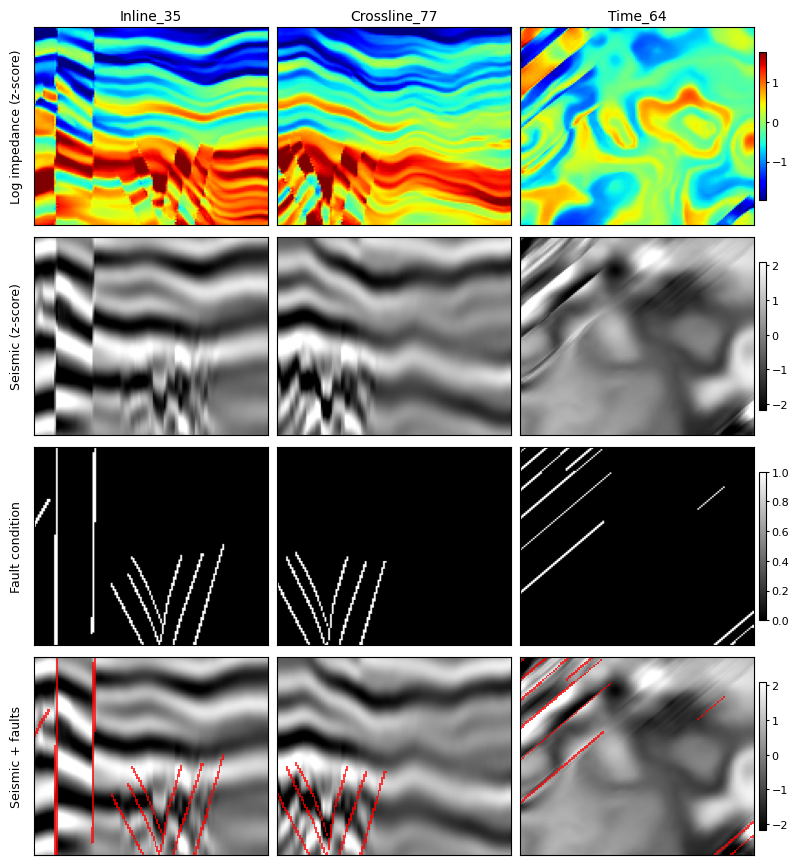

In [197]:
preview_split = 'train' if cfg.num_samples else 'valid'
preview_index = cfg.last_sample
sample_dir = Path(cfg.save_root) / preview_split / f'{preview_index:04d}'
preview_sample(sample_dir, pos=[35, 77, 64])
